# Refuerzo 2 · Jerárquico: explorar distintas resoluciones
**90 minutos autónomos.** Interprete un dendrograma, compare enlaces y derive Ward.
Trabajamos con una submuestra fija de 500 puntos. Las conclusiones describen esa submuestra.

In [1]:
from pathlib import Path
import sys, time, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from threadpoolctl import threadpool_limits

# Funciona desde la raíz, desde esta carpeta o desde docente/.
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / 'datasets/semana-08').is_dir())
sys.path.insert(0, str(ROOT / 'notebooks/semana-08'))
from movilidad import (load_data, setup, savefig, save_table, spatial_axes,
                       ellipses, safe_silhouette, density_grid, COLORS, DATA)
setup()
threadpool_limits(limits=2)
frame = load_data()
X = frame[['x_km', 'y_km']].to_numpy()
print(f'Desarrollo: {len(frame):,} recogidas. Unidades: km. Semilla: 42.')
print('Test temporal cerrado hasta congelar el modelo.')
display(frame.head(3))

Desarrollo: 6,000 recogidas. Unidades: km. Semilla: 42.
Test temporal cerrado hasta congelar el modelo.


,source_row,pickup_datetime,pickup_longitude,pickup_latitude,x_km,y_km,fare_amount,passenger_count,dropoff_longitude,dropoff_latitude
0,32038,2014-01-01 00:01:00+00:00,-73.991493,40.735202,0.156182,-0.148260,5.5,5,-74.001727,40.727767
1,132584,2014-01-01 00:29:37+00:00,-74.008090,40.740434,-1.251817,0.416562,8.0,2,-73.996088,40.726627
2,190530,2014-01-01 00:54:07+00:00,-73.981944,40.778096,0.907251,4.622599,7.5,1,-73.967887,40.801430


## Construcción aglomerativa y enlaces
Comenzamos con un grupo por observación y fusionamos dos grupos en cada paso.
Simple usa la distancia mínima entre pares; completo, la máxima; promedio, la media de todas las distancias
entre pares. Ward minimiza el incremento de suma de cuadrados:
$$\Delta(A,B)=\frac{n_A n_B}{n_A+n_B}\|\mu_A-\mu_B\|^2.$$
La identidad se obtiene al descomponer la suma de cuadrados respecto de la media conjunta.
En SciPy, la altura de enlace Ward es $\sqrt{2\Delta}$, no $\Delta$.
El enfoque divisivo empieza con todos los puntos y divide; lo estudiamos conceptualmente.

### Para resolver

Para A={0,2} y B={5}, calcule el incremento de Ward y la altura que mostraría SciPy para esa fusión.

**Mi respuesta y evidencia:**

_Escriba aquí su razonamiento; incluya unidades y una limitación._

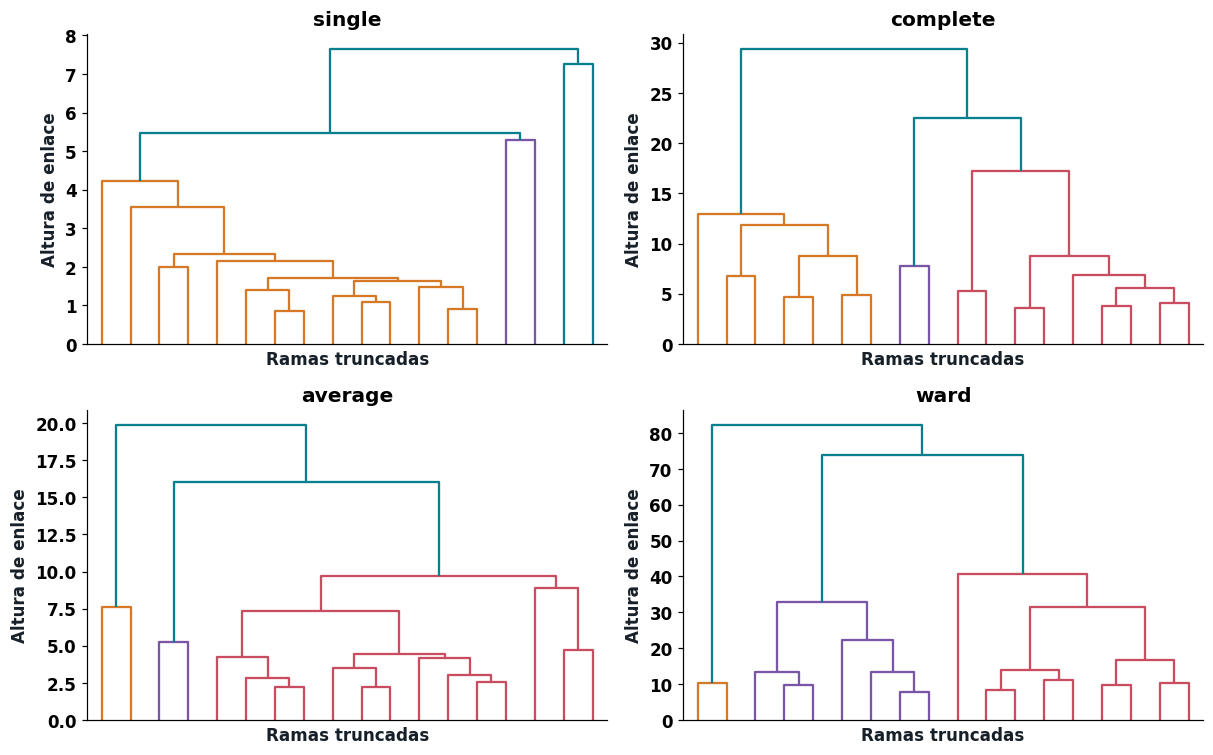

In [2]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
small=load_data('jerarquico'); Z=small[['x_km','y_km']].to_numpy()
fig,axes=plt.subplots(2,2,figsize=(11,7))
for ax,method in zip(axes.ravel(),['single','complete','average','ward']):
    tree=linkage(Z,method=method,metric='euclidean')
    dendrogram(tree,truncate_mode='lastp',p=18,ax=ax,no_labels=True)
    ax.set(title=method,xlabel='Ramas truncadas',ylabel='Altura de enlace')
fig.tight_layout(); savefig(fig,'16_dendrogramas')

## Cortar el árbol y leer la partición
La distancia vertical mide el criterio de enlace. La posición horizontal es un orden de hojas, no una distancia
espacial. Un corte por altura no equivale al mismo número de grupos en todos los enlaces.
`maxclust` solicita a lo sumo K grupos; compruebe cuántos produce realmente si hay empates.

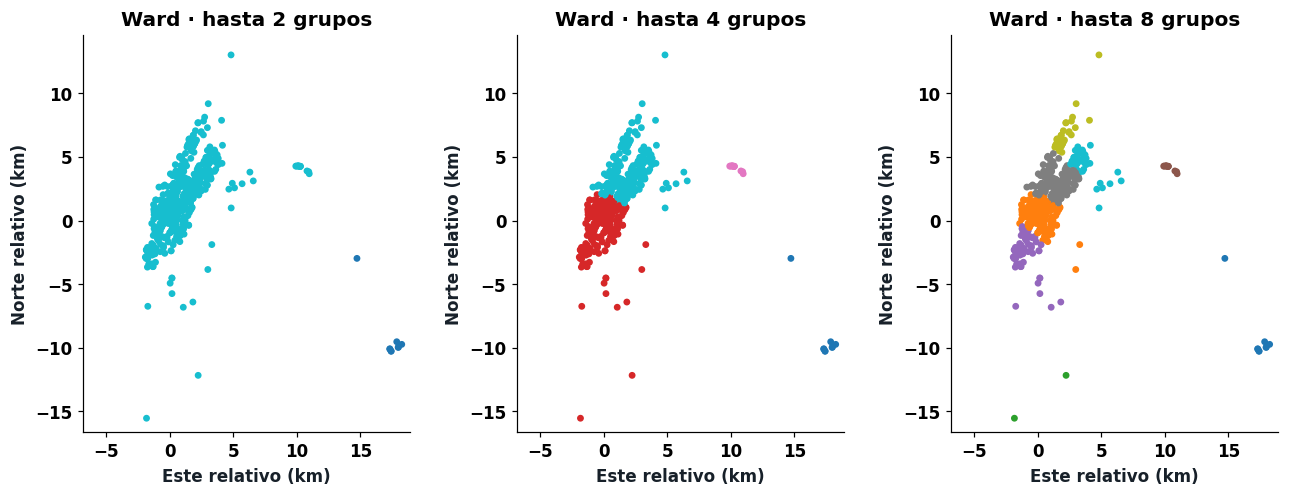

,requested_k,actual_k,silhouette
0,2,2,0.801015
1,4,4,0.478182
2,8,8,0.409621


Fusiones del ejemplo manual: [[0.         1.         2.         2.        ]
 [2.         3.         4.61880215 3.        ]]


In [3]:
tree=linkage(Z,method='ward',metric='euclidean')
rows=[]
fig,axes=plt.subplots(1,3,figsize=(12,4.5))
for ax,k in zip(axes,[2,4,8]):
    labels=fcluster(tree,t=k,criterion='maxclust')
    rows.append(dict(requested_k=k,actual_k=len(np.unique(labels)),silhouette=safe_silhouette(Z,labels)))
    ax.scatter(*Z.T,c=labels,cmap='tab10',s=12)
    spatial_axes(ax,X,f'Ward · hasta {k} grupos')
fig.tight_layout(); savefig(fig,'17_ward_espacial')
display(pd.DataFrame(rows)); save_table(pd.DataFrame(rows),'jerarquico_cortes')
ward_toy=linkage(np.array([0.,2.,5.])[:,None],method='ward')
assert np.isclose(ward_toy[-1,2],np.sqrt(64/3))
print('Fusiones del ejemplo manual:',ward_toy)

### Para resolver

¿Por qué enlace simple produce encadenamiento? ¿Por qué no usar Ward con haversine? ¿Es comparable la silhouette de estos 500 puntos con la de 6000?

**Mi respuesta y evidencia:**

_Escriba aquí su razonamiento; incluya unidades y una limitación._

In [4]:
from sklearn.cluster import KMeans
km=KMeans(4,n_init=10,random_state=42).fit_predict(Z)
ward=fcluster(tree,t=4,criterion='maxclust')
print('Misma submuestra, silhouette K-means:',safe_silhouette(Z,km))
print('Misma submuestra, silhouette Ward:',safe_silhouette(Z,ward))

Misma submuestra, silhouette K-means: 0.4203541509346418
Misma submuestra, silhouette Ward: 0.4781816948732615


D:\Documentos\Universidad Externado\Pregrado en Ciencia de Datos\Machine Learning 2\.venv-week4\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "D:\Documentos\Universidad Externado\Pregrado en Ciencia de Datos\Machine Learning 2\.venv-week4\Lib\site-packages\joblib\externals\loky\backend\context.py", line 255, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


## Fuentes y reproducción
- Microcurrículo y guía docente ML2, sesiones 19–24; adaptación del cuaderno histórico del profesor.
- [GMM](https://scikit-learn.org/stable/modules/mixture.html), [KDE](https://scikit-learn.org/stable/modules/density.html), [clustering](https://scikit-learn.org/stable/modules/clustering.html).
- Dataset suministrado por el docente; ver `datasets/semana-08/README.md` y `manifest.json`.
- Dependencias fijadas en `requirements-week8.txt`. Inicie el kernel en una carpeta del paquete.